<a href="https://colab.research.google.com/github/Mahadevkharmate/DeepLearning_Hub/blob/main/tutorials/001_intro_to_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Perceptron

[Perceptron vs neuron, Single layer Perceptron and Multi Layer Perceptron](https://medium.com/@abhishekjainindore24/perceptron-vs-neuron-single-layer-perceptron-and-multi-layer-perceptron-68ce4e8db5ea)

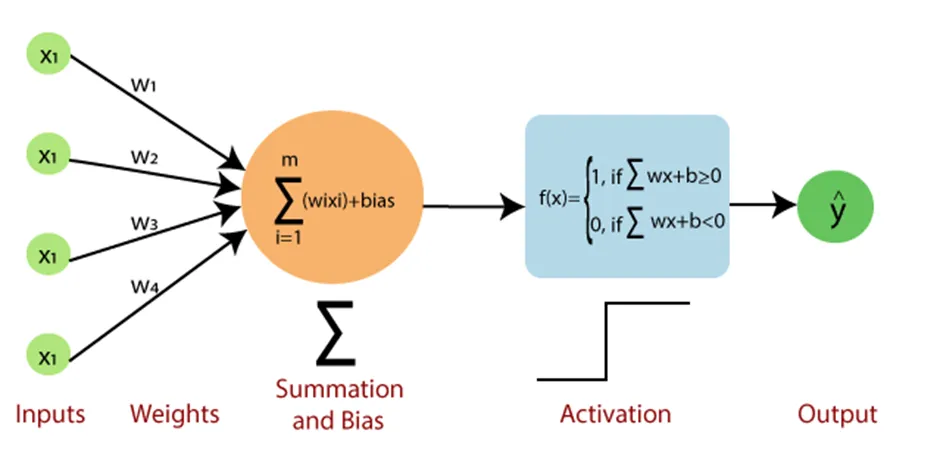

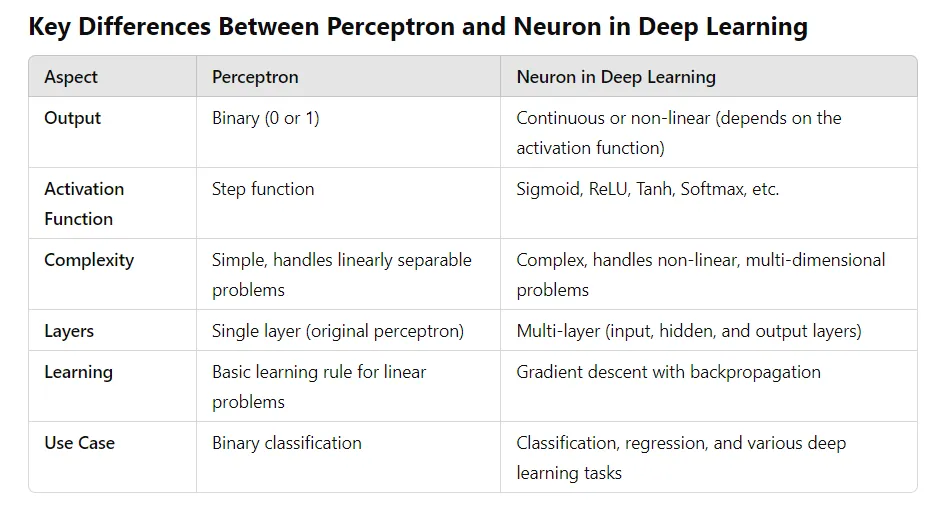

__Perceptron__ Implementation

In [ ]:
import numpy as np

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        self.weights = np.random.rand(input_size)
        self.bias = np.random.rand()
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation_function(self, x):
        return 1 if x >= 0 else 0  # Step function

    def predict(self, X):
        weighted_sum = np.dot(X, self.weights) + self.bias
        return self.activation_function(weighted_sum)

    def train(self, X_train, y_train):
        for _ in range(self.epochs):
            for X, y in zip(X_train, y_train):
                y_pred = self.predict(X)
                error = y - y_pred  # Compute error

                # Update weights and bias using perceptron learning rule
                self.weights += self.learning_rate * error * X
                self.bias += self.learning_rate * error

# Training Data (AND Gate)
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([0, 0, 0, 1])  # AND gate outputs

perceptron = Perceptron(input_size=2)
perceptron.train(X_train, y_train)

# Testing the perceptron
for x in X_train:
    print(f"Input: {x}, Predicted Output: {perceptron.predict(x)}")


Input: [0 0], Predicted Output: 0
Input: [0 1], Predicted Output: 0
Input: [1 0], Predicted Output: 0
Input: [1 1], Predicted Output: 1


🎯 Summary
✅ The perceptron learns the AND gate by adjusting weights & bias.
✅ It updates only when predictions are incorrect.
✅ After multiple iterations, it correctly classifies all inputs.

[Preceptron trick](https://github.com/campusx-official/100-days-of-deep-learning/blob/main/day4/perceptron-trick.ipynb)

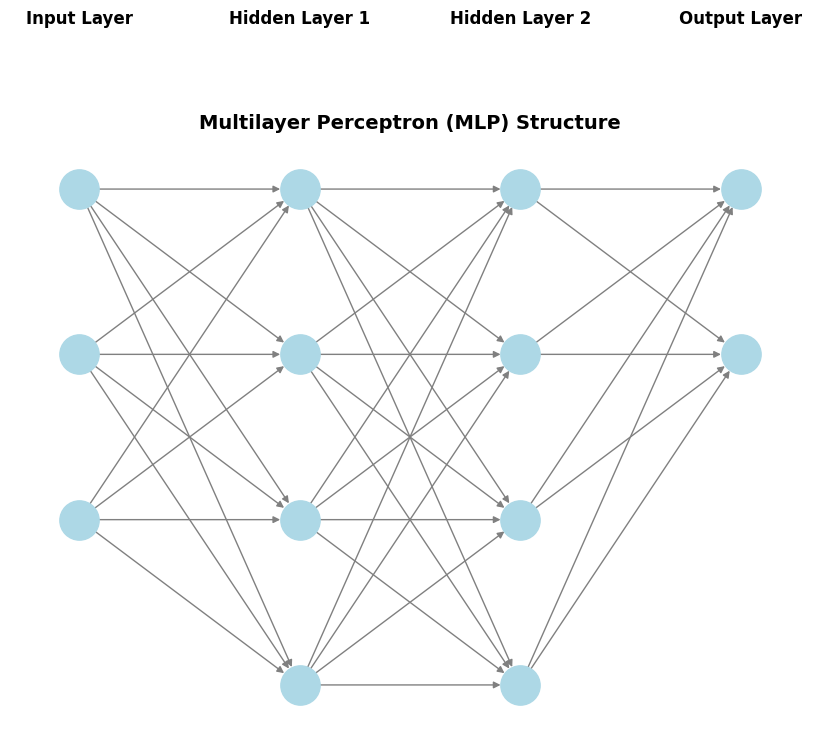

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_mlp(layers):
    G = nx.DiGraph()
    pos = {}  # Dictionary to store node positions
    layer_x = 0  # X-coordinate for layers

    # Generate node positions and edges
    prev_layer_nodes = []
    for i, num_nodes in enumerate(layers):
        layer_nodes = [(layer_x, y) for y in range(num_nodes)]
        pos.update({(layer_x, y): (layer_x, -y) for y in range(num_nodes)})
        G.add_nodes_from(layer_nodes)

        # Connect nodes from previous layer to current layer
        if prev_layer_nodes:
            for prev_node in prev_layer_nodes:
                for curr_node in layer_nodes:
                    G.add_edge(prev_node, curr_node)

        prev_layer_nodes = layer_nodes
        layer_x += 1  # Move to next layer

    # Draw the network
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=False, node_size=800, edge_color="gray", node_color="lightblue")

    # Labeling layers
    labels = ["Input Layer"] + [f"Hidden Layer {i}" for i in range(1, len(layers) - 1)] + ["Output Layer"]
    for i, label in enumerate(labels):
        plt.text(i, 1, label, fontsize=12, ha="center", fontweight="bold")

    plt.title("Multilayer Perceptron (MLP) Structure", fontsize=14, fontweight="bold")
    plt.show()

# Define layers: (Input, Hidden1, Hidden2, Output)
draw_mlp([3, 4, 4, 2])


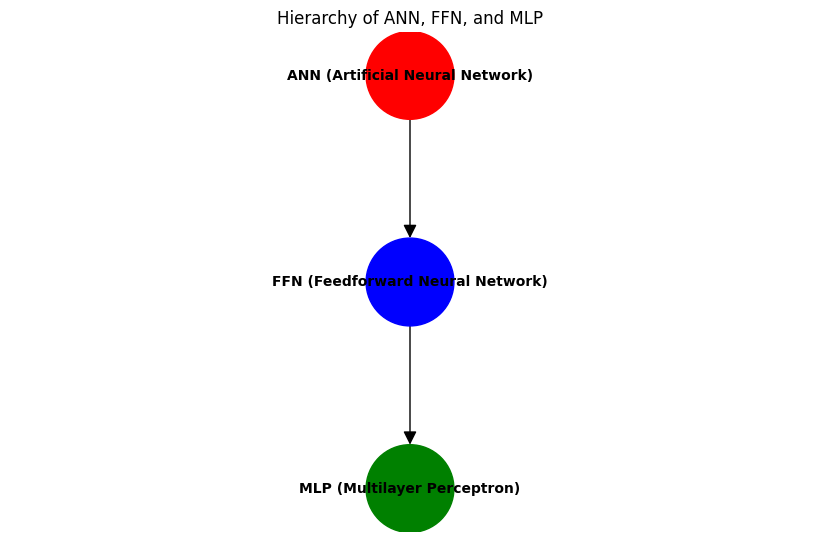

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Define nodes for ANN, FFN, and MLP
G.add_node("ANN (Artificial Neural Network)", color="red")
G.add_node("FFN (Feedforward Neural Network)", color="blue")
G.add_node("MLP (Multilayer Perceptron)", color="green")

# Define edges to show hierarchy
G.add_edge("ANN (Artificial Neural Network)", "FFN (Feedforward Neural Network)")
G.add_edge("FFN (Feedforward Neural Network)", "MLP (Multilayer Perceptron)")

# Get node colors
node_colors = [G.nodes[node]["color"] for node in G.nodes]

# Plot the graph
plt.figure(figsize=(8, 5))
pos = {"ANN (Artificial Neural Network)": (0, 2), "FFN (Feedforward Neural Network)": (0, 1), "MLP (Multilayer Perceptron)": (0, 0)}
nx.draw(G, pos, with_labels=True, node_size=4000, node_color=node_colors, edge_color="black", font_size=10, font_weight="bold", arrowsize=20)

plt.title("Hierarchy of ANN, FFN, and MLP")
plt.show()


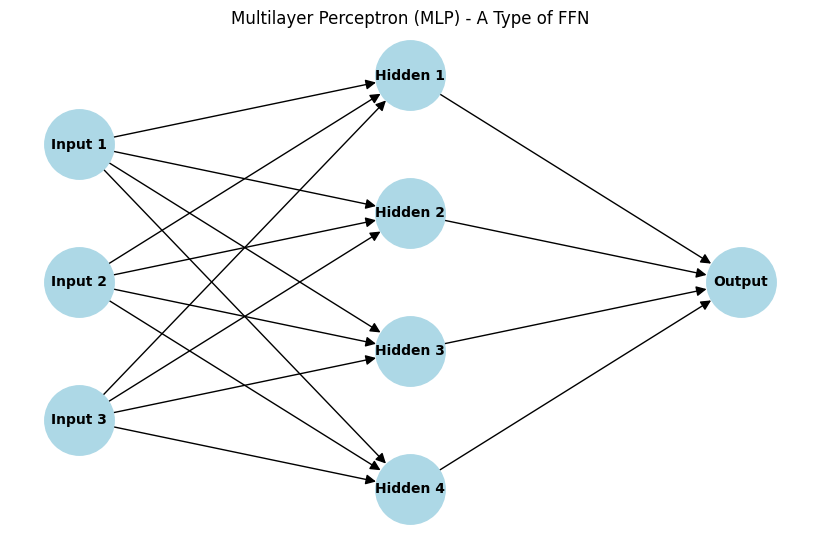

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_mlp():
    # Create a directed graph
    G = nx.DiGraph()

    # Define layers
    input_nodes = ["Input 1", "Input 2", "Input 3"]
    hidden_nodes = ["Hidden 1", "Hidden 2", "Hidden 3", "Hidden 4"]
    output_nodes = ["Output"]

    # Add nodes to graph
    for node in input_nodes + hidden_nodes + output_nodes:
        G.add_node(node)

    # Connect input layer to hidden layer
    for input_node in input_nodes:
        for hidden_node in hidden_nodes:
            G.add_edge(input_node, hidden_node)

    # Connect hidden layer to output layer
    for hidden_node in hidden_nodes:
        for output_node in output_nodes:
            G.add_edge(hidden_node, output_node)

    # Define node positions for better visualization
    pos = {}
    for i, node in enumerate(input_nodes):
        pos[node] = (0, -i)
    for i, node in enumerate(hidden_nodes):
        pos[node] = (1, -i + 0.5)
    for i, node in enumerate(output_nodes):
        pos[node] = (2, -1)

    # Draw the graph
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2500, node_color="lightblue", font_size=10, font_weight="bold", edge_color="black", arrowsize=15)

    plt.title("Multilayer Perceptron (MLP) - A Type of FFN")
    plt.show()

# Call the function to draw the MLP
draw_mlp()


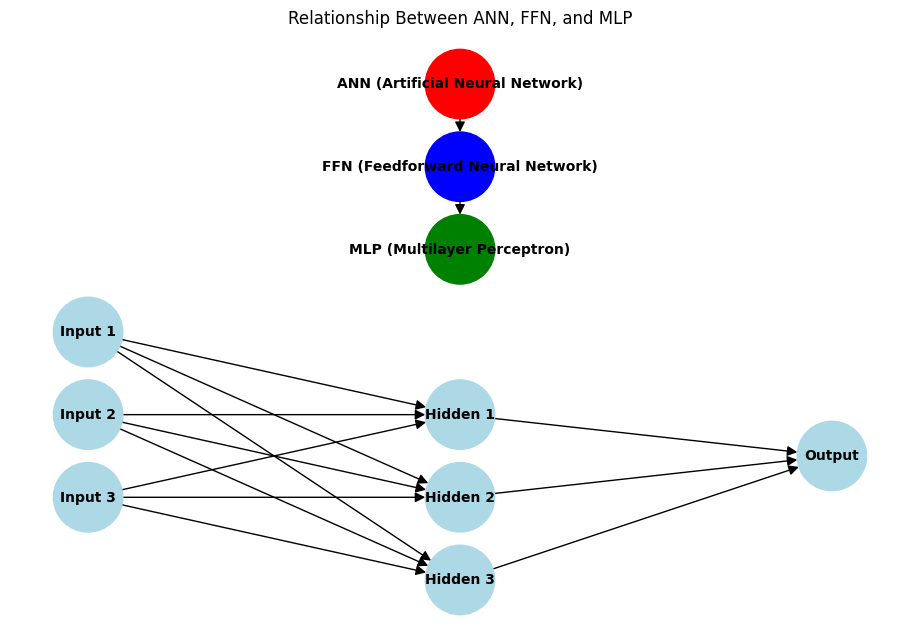

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_ann_ffn_mlp():
    # Create a directed graph
    G = nx.DiGraph()

    # Define categories
    G.add_node("ANN (Artificial Neural Network)", color="red")
    G.add_node("FFN (Feedforward Neural Network)", color="blue")
    G.add_node("MLP (Multilayer Perceptron)", color="green")

    # Define layers in MLP
    input_nodes = ["Input 1", "Input 2", "Input 3"]
    hidden_nodes = ["Hidden 1", "Hidden 2", "Hidden 3"]
    output_nodes = ["Output"]

    # Add nodes to graph
    for node in input_nodes + hidden_nodes + output_nodes:
        G.add_node(node, color="lightblue")

    # Connect ANN → FFN → MLP
    G.add_edge("ANN (Artificial Neural Network)", "FFN (Feedforward Neural Network)")
    G.add_edge("FFN (Feedforward Neural Network)", "MLP (Multilayer Perceptron)")

    # Connect input layer to hidden layer
    for input_node in input_nodes:
        for hidden_node in hidden_nodes:
            G.add_edge(input_node, hidden_node)

    # Connect hidden layer to output layer
    for hidden_node in hidden_nodes:
        for output_node in output_nodes:
            G.add_edge(hidden_node, output_node)

    # Define node positions
    pos = {
        "ANN (Artificial Neural Network)": (0, 3),
        "FFN (Feedforward Neural Network)": (0, 2),
        "MLP (Multilayer Perceptron)": (0, 1),
    }
    for i, node in enumerate(input_nodes):
        pos[node] = (-1, -i)
    for i, node in enumerate(hidden_nodes):
        pos[node] = (0, -i - 1)
    for i, node in enumerate(output_nodes):
        pos[node] = (1, -1.5)

    # Get node colors
    node_colors = [G.nodes[node].get("color", "gray") for node in G.nodes]

    # Draw the graph
    plt.figure(figsize=(9, 6))
    nx.draw(G, pos, with_labels=True, node_size=2500, node_color=node_colors, font_size=10, font_weight="bold", edge_color="black", arrowsize=15)

    plt.title("Relationship Between ANN, FFN, and MLP")
    plt.show()

# Call function to draw the visualization
draw_ann_ffn_mlp()


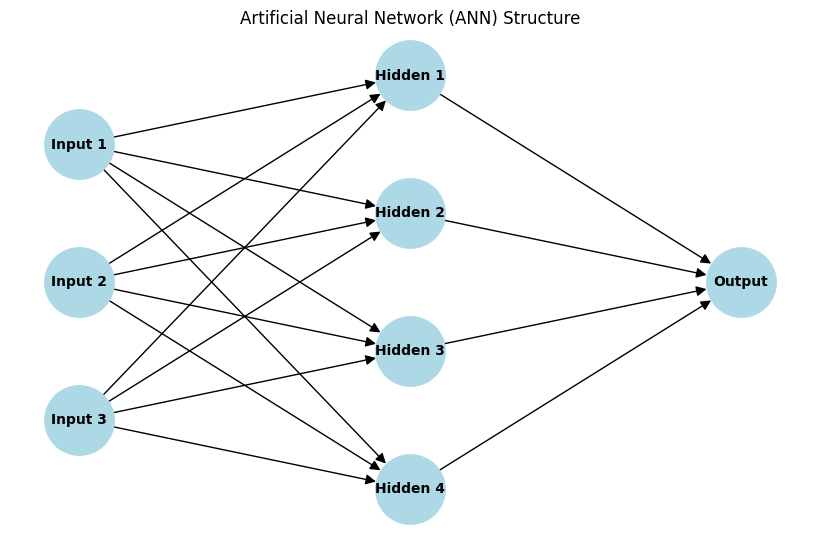

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_ann():
    # Create a directed graph
    G = nx.DiGraph()

    # Define layers of ANN
    input_nodes = ["Input 1", "Input 2", "Input 3"]
    hidden_nodes = ["Hidden 1", "Hidden 2", "Hidden 3", "Hidden 4"]
    output_nodes = ["Output"]

    # Add nodes to graph
    for node in input_nodes + hidden_nodes + output_nodes:
        G.add_node(node)

    # Connect input layer to hidden layer
    for input_node in input_nodes:
        for hidden_node in hidden_nodes:
            G.add_edge(input_node, hidden_node)

    # Connect hidden layer to output layer
    for hidden_node in hidden_nodes:
        for output_node in output_nodes:
            G.add_edge(hidden_node, output_node)

    # Define node positions for visualization
    pos = {}
    for i, node in enumerate(input_nodes):
        pos[node] = (0, -i)
    for i, node in enumerate(hidden_nodes):
        pos[node] = (1, -i + 0.5)
    for i, node in enumerate(output_nodes):
        pos[node] = (2, -1)

    # Draw the graph
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2500, node_color="lightblue", font_size=10, font_weight="bold", edge_color="black", arrowsize=15)

    plt.title("Artificial Neural Network (ANN) Structure")
    plt.show()

# Call function to draw the ANN visualization
draw_ann()


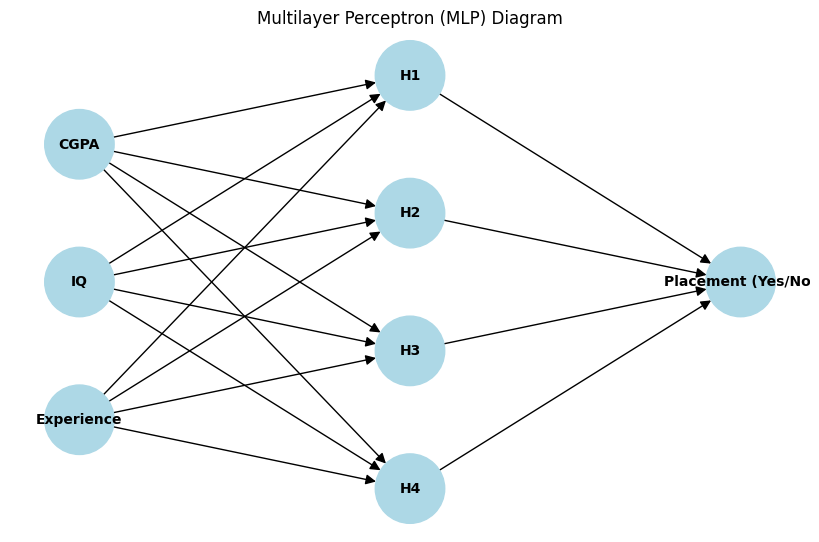

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_mlp():
    # Create a directed graph
    G = nx.DiGraph()

    # Define layers
    input_nodes = ["CGPA", "IQ", "Experience"]
    hidden_nodes = ["H1", "H2", "H3", "H4"]
    output_nodes = ["Placement (Yes/No)"]

    # Add nodes to graph
    for node in input_nodes + hidden_nodes + output_nodes:
        G.add_node(node, color="lightblue")

    # Connect input layer to hidden layer
    for input_node in input_nodes:
        for hidden_node in hidden_nodes:
            G.add_edge(input_node, hidden_node)

    # Connect hidden layer to output layer
    for hidden_node in hidden_nodes:
        for output_node in output_nodes:
            G.add_edge(hidden_node, output_node)

    # Define node positions for better visualization
    pos = {}
    for i, node in enumerate(input_nodes):
        pos[node] = (0, -i)
    for i, node in enumerate(hidden_nodes):
        pos[node] = (1, -i + 0.5)
    for i, node in enumerate(output_nodes):
        pos[node] = (2, -1)

    # Get node colors
    node_colors = [G.nodes[node].get("color", "gray") for node in G.nodes]

    # Draw the graph
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2500, node_color=node_colors, font_size=10, font_weight="bold", edge_color="black", arrowsize=15)

    plt.title("Multilayer Perceptron (MLP) Diagram")
    plt.show()

# Call the function to draw the MLP
draw_mlp()


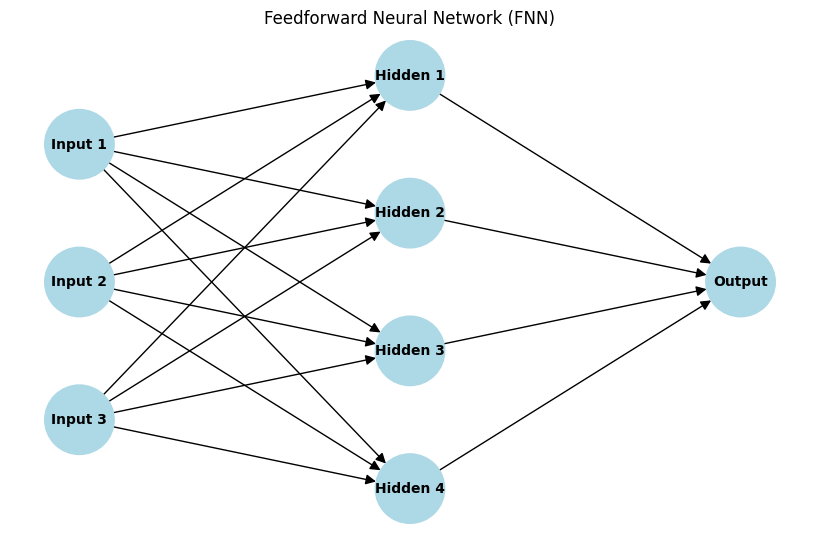

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_fnn():
    # Create a directed graph
    G = nx.DiGraph()

    # Define layers
    input_nodes = ["Input 1", "Input 2", "Input 3"]
    hidden_nodes = ["Hidden 1", "Hidden 2", "Hidden 3", "Hidden 4"]
    output_nodes = ["Output"]

    # Add nodes to graph
    for node in input_nodes + hidden_nodes + output_nodes:
        G.add_node(node, color="lightblue")

    # Connect input layer to hidden layer
    for input_node in input_nodes:
        for hidden_node in hidden_nodes:
            G.add_edge(input_node, hidden_node)

    # Connect hidden layer to output layer
    for hidden_node in hidden_nodes:
        for output_node in output_nodes:
            G.add_edge(hidden_node, output_node)

    # Define node positions
    pos = {}
    for i, node in enumerate(input_nodes):
        pos[node] = (-1, -i)
    for i, node in enumerate(hidden_nodes):
        pos[node] = (0, -i + 0.5)
    for i, node in enumerate(output_nodes):
        pos[node] = (1, -1)

    # Get node colors
    node_colors = [G.nodes[node].get("color", "gray") for node in G.nodes]

    # Draw the graph
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2500, node_color=node_colors, font_size=10, font_weight="bold", edge_color="black", arrowsize=15)

    plt.title("Feedforward Neural Network (FNN)")
    plt.show()

# Call the function to draw the FNN diagram
draw_fnn()
